## From TT optimized models, can simulate and visualize different spiking neural datasets

* need to match these w the parameters in real-life experiments

In [3]:
TT_NODE = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"

node_sim_data = "/scratch/gpfs/ad2002/content/datasets/dt/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"

# currently have heldin_50_heldout_10_obs_noise_pseudoPoisson_dispersion_1.0_seed_0.h5

In [132]:
from ctd.task_modeling.simulator.neural_simulator import NeuralDataSimulator
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# always runs with seed=0
def simulate(tt_model_path="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True",
             tt_dataset_path="/scratch/gpfs/ad2002/content/datasets/dt",
             tt_run_tag="20250407_PC_NODE_grid_final",
             tune_name="max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True",
             
             embed_dict={
                 "fr_scaling": 0.5,  # Scaling factor for firing rates
                 "rect_func": "softplus"  # Nonlinearity for rectification (options: "exp", "sigmoid", "softplus")
             },
             noise_dict={
                 "obs_noise": "poisson",  # Observation noise model (options: "poisson", "pseudoPoisson")
                 "dispersion": 0.1  # Dispersion parameter for pseudo-Poisson noise
             },
             neuron_dict={
                 "n_neurons_heldin": 300,
                 "n_neurons_heldout": 50,
             },
             trim_inds=None,
            ):
    
    """Simulate and save a spiking dataset from the latents of a task-trained model
    
    Returns:
        data (np.ndarray): the spiking dataset (n_trials, timesteps, total_neurons)
        inputs (np.ndarray): TT model inputs, correspond to the data
        activity (np.ndarray): rectified neural rates
        latents (np.ndarray): TT model latents
    """
    
    # load model
    with open(tt_model_path + "/model.pkl", "rb") as f:
        task_trained_model = pickle.load(f)
            
    # load datamodule
    with open(tt_model_path + "/datamodule_sim.pkl", "rb") as f:
        datamodule = pickle.load(f)
        datamodule.prepare_data()
        datamodule.setup()
    
    # create simulator object
    simulator = NeuralDataSimulator(neuron_dict, embed_dict, noise_dict, trim_inds)
    
    return simulator.simulate_neural_data(task_trained_model, datamodule, tt_run_tag, tune_name, tt_dataset_path, seed=0)


def raster_plot(spike_data, input_data, n_trials_to_plot=None, neurons_to_plot=3, figsize=(18, 12)):
    """
    Create raster plots of neuronal activity with corresponding input signals.
    Trials are plotted in a single column.
    
    Parameters:
    -----------
    spike_data : numpy.ndarray
        Array of shape (n_trials, timesteps, n_neurons) containing spike data
        where 1 indicates a spike and 0 indicates no spike.
    input_data : numpy.ndarray
        Array of shape (n_trials, timesteps, input_dim) containing input signals.
    n_trials_to_plot : int or None
        Number of trials to plot. If None, all trials are plotted.
    neurons_to_plot : int
        Number of neurons to plot (from the beginning of the array)
    figsize : tuple
        Figure size (width, height) in inches
    """
    n_trials, timesteps, n_neurons = spike_data.shape
    _, _, input_dim = input_data.shape
    
    # Handle how many trials to plot
    if n_trials_to_plot is None:
        n_trials_to_plot = n_trials
    else:
        n_trials_to_plot = min(n_trials_to_plot, n_trials)
    
    # Handle how many neurons to plot
    neurons_to_plot = min(neurons_to_plot, n_neurons)
    
    # Create figure with GridSpec for flexible subplot layout
    fig = plt.figure(figsize=figsize)
    
    # Create a grid with 2*n_trials_to_plot rows (2 for each trial - spikes and inputs)
    # and 1 column
    gs = gridspec.GridSpec(2*n_trials_to_plot, 1, height_ratios=[3, 2] * n_trials_to_plot)
    
    # Plot each trial
    for trial_idx in range(n_trials_to_plot):
        # Calculate the position in the grid for this trial
        spike_row = 2 * trial_idx
        input_row = 2 * trial_idx + 1
        
        # Create subplot for spike data
        ax_spikes = fig.add_subplot(gs[spike_row, 0])
        
        # Extract spike data for the current trial, limited to the selected neurons
        trial_spike_data = spike_data[trial_idx, :, :neurons_to_plot]
        
        # For each neuron
        for neuron_idx in range(neurons_to_plot):
            # Find the spike times for this neuron
            spike_times = np.where(trial_spike_data[:, neuron_idx] > 0)[0]
            
            # Plot spikes as dots
            ax_spikes.scatter(spike_times, np.ones_like(spike_times) * neuron_idx, 
                           marker='.', color='black', s=10)
        
        # Set title for the spike plot
        ax_spikes.set_title(f'Trial {trial_idx+1}')
        
        # Set y labels for all subplots
        ax_spikes.set_ylabel('Neurons')
        
        # Set limits
        ax_spikes.set_xlim(0, timesteps)
        ax_spikes.set_ylim(-0.5, neurons_to_plot - 0.5)
        
        # Show proper timestamps on x-axis
        # Only show x tick labels for the input plots of each trial
        ax_spikes.set_xticklabels([])
        
        # Create subplot for input data
        ax_inputs = fig.add_subplot(gs[input_row, 0], sharex=ax_spikes)
        
        # Extract input data for the current trial
        trial_input_data = input_data[trial_idx]
        click_times_fix = np.where(trial_input_data[:,0] > 0.5)[0]
        click_times_left = np.where(trial_input_data[:,1] > 0.5)[0]
        click_times_right = np.where(trial_input_data[:,2] > 0.5)[0]                                                    
        
        ax_inputs.scatter(click_times_left, -0.25*np.ones_like(click_times_left), 
                           marker='|', color='blue', s=10)
        ax_inputs.scatter(click_times_right, 0.25*np.ones_like(click_times_right), 
                           marker='|', color='red', s=10)
        
        ax_inputs.set_xlim(0, timesteps)
        ax_inputs.set_ylim(-0.5, 0.5)
        
        # Set y label for all input subplots
        ax_inputs.set_ylabel('Clicks')
        
        # Show proper timestamps on x-axis
#         # Only show complete x-axis labels on the bottom-most subplot
#         if trial_idx < n_trials_to_plot - 1:
#             ax_inputs.set_xticklabels([])
#         else:
#             # For the last subplot, show the full x-axis with timestamps
#             ax_inputs.set_xlabel('Timesteps ($\Delta t=10~ms$)')
            
        # Add legend only to the first subplot to avoid repetition
        if trial_idx == 0 and input_dim <= 5:
            ax_inputs.legend(loc='best', fontsize='small')
    
    plt.tight_layout()
    
    return fig

In [135]:
# softplus, poisson, dispersion=1.0 for best fit (overdispersion=0) in Luo et al (fano=1.0 for Pois, in theory)

for i,j in [[150,150], [200,100], [250,50], [280,20]]:
    spike_data, inputs, activity, latents = simulate(
                 embed_dict={
                     "fr_scaling": 1.0,  # mean to variance ratio for the embeddings
                     "rect_func": "softplus"  # Nonlinearity for rectification (options: "exp", "sigmoid", "softplus")
                 },
                 noise_dict={
                     "obs_noise": "poisson",  # Observation noise model (options: "poisson", "pseudoPoisson")
                     "dispersion": 1.0  # =1 for Poisson
                 },
                 neuron_dict={
                     "n_neurons_heldin": i,
                     "n_neurons_heldout": j,
                 },)

/tmp/ipykernel_1134371/4266173861.py:156: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_inputs.legend(loc='best', fontsize='small')


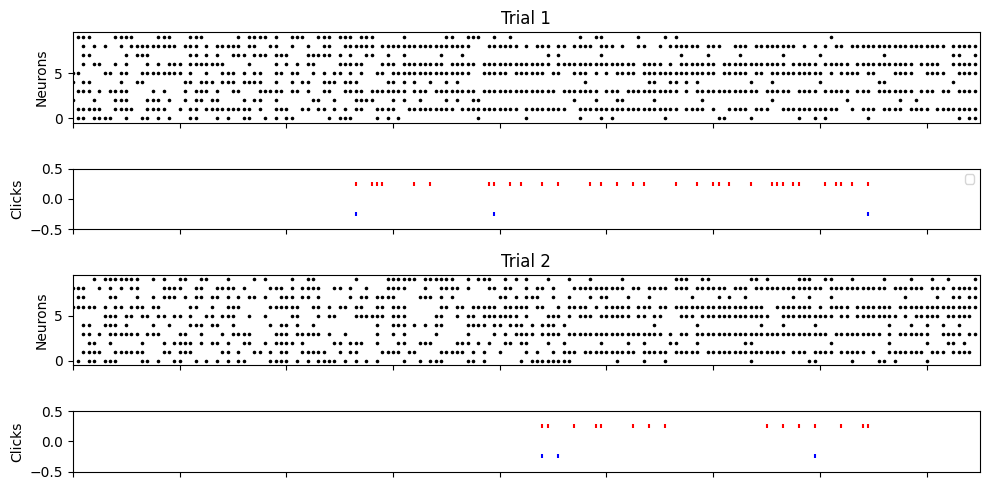

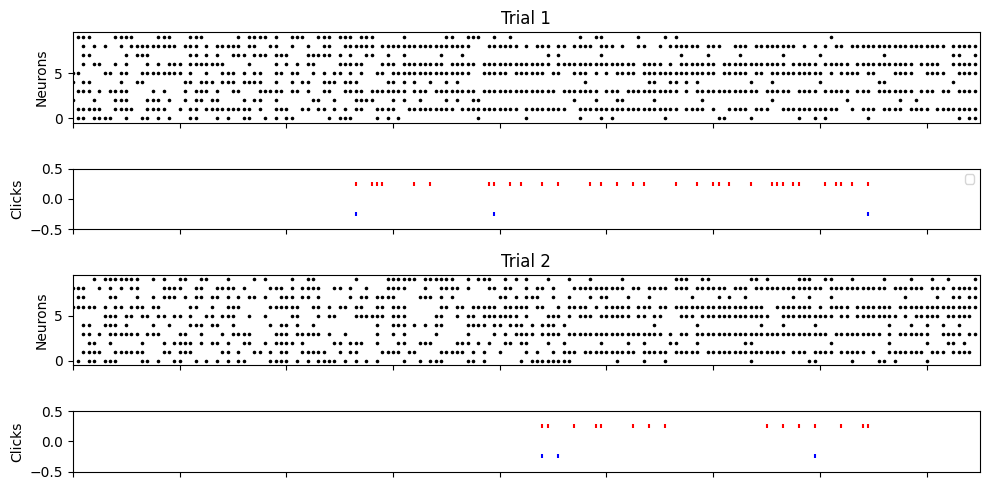

In [133]:
raster_plot(spike_data, inputs, n_trials_to_plot=2, neurons_to_plot=10, figsize=(10,5))

# all neurons have the same sudden change for ONE trial
# it varies across trials

# ex below for 10 neurons from first 3 trials (as many trials as input trials in TT)